# Resume Screening and Candidate Ranking System Using Machine Learning

## Project Overview

Recruiters receive hundreds of resumes for a single job opening. Manually reviewing every resume is time-consuming and inefficient.

This project develops a Resume Screening and Candidate Ranking System using Natural Language Processing (NLP) and Machine Learning techniques.

The system automatically:

- Cleans and preprocesses resume text
- Extracts useful information
- Matches resumes with a job description
- Calculates similarity scores
- Ranks candidates based on job relevance
- Identifies missing skills

This project demonstrates how Machine Learning can assist HR teams in making faster and better hiring decisions.

In [1]:
from google.colab import files

uploaded = files.upload()

Saving Resume.csv to Resume.csv


# Import Required Libraries

The required Python libraries are imported for data analysis, text preprocessing, visualization, and machine learning.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

# Load Resume Dataset

The dataset is loaded into a Pandas DataFrame for further preprocessing and analysis.

In [4]:
df = pd.read_csv("Resume.csv")

df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


# 3. Dataset Overview

This section provides an overview of the dataset, including its shape, columns, data types, and basic statistics. Understanding the dataset helps in planning preprocessing and feature extraction.

In [5]:
print("Shape of Dataset:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:\n")
df.info()

Shape of Dataset: (2484, 4)

Columns:
Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')

Data Types:
ID              int64
Resume_str     object
Resume_html    object
Category       object
dtype: object

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


# 4. Data Cleaning

The dataset is checked for:

- Missing values
- Duplicate records
- Data consistency

Cleaning the data improves the quality of the machine learning model.

In [6]:
# Missing Values

print(df.isnull().sum())

ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64


In [7]:
# Duplicate Rows

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [8]:
# Remove duplicates

df = df.drop_duplicates()

print("New Shape :", df.shape)

New Shape : (2484, 4)


# 5. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the distribution of resumes across different job categories.

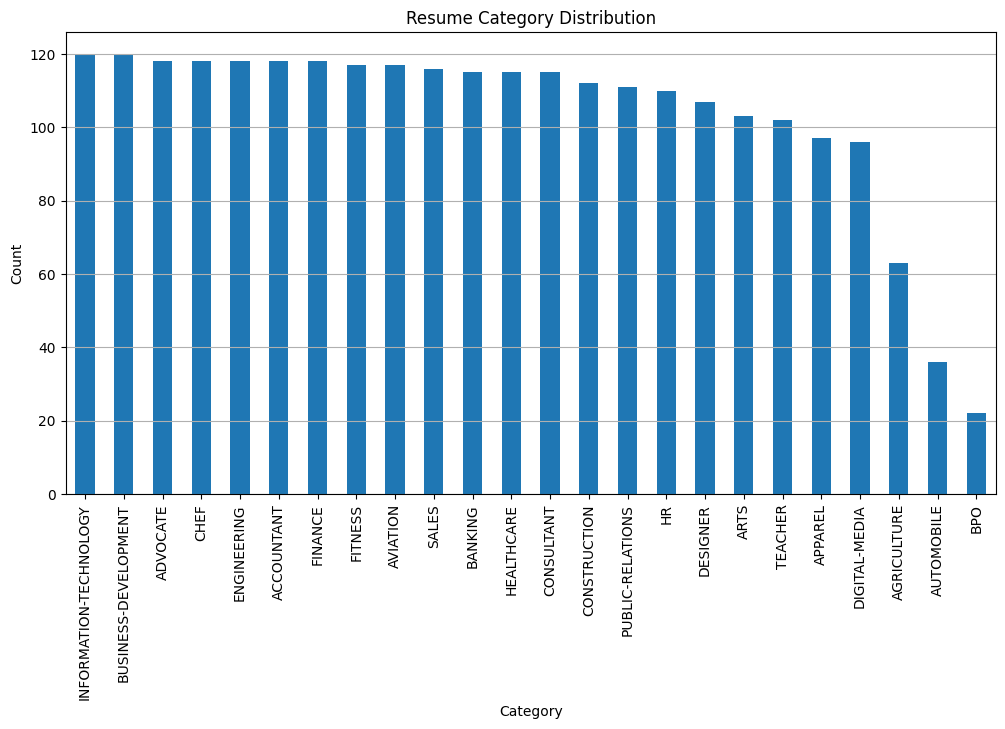

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

df["Category"].value_counts().plot(kind="bar")

plt.title("Resume Category Distribution")

plt.xlabel("Category")

plt.ylabel("Count")

plt.xticks(rotation=90)

plt.grid(axis="y")

plt.show()

# 6. Text Preprocessing

The resume text is cleaned before feature extraction.

The preprocessing steps include:

- Lowercase conversion
- Removing URLs
- Removing punctuation
- Removing numbers
- Removing extra spaces
- Tokenization
- Stopword removal

These steps improve the quality of text features.

In [10]:
import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("punkt_tab")

stop_words = set(stopwords.words("english"))

print("Libraries Loaded Successfully!")

Libraries Loaded Successfully!


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [11]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"\d+", "", text)

    text = text.translate(str.maketrans("", "", string.punctuation))

    words = word_tokenize(text)

    words = [word for word in words if word not in stop_words]

    return " ".join(words)


df["Clean_Resume"] = df["Resume_str"].apply(clean_text)

df[["Resume_str","Clean_Resume"]].head()

,Resume_str,Clean_Resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,hr administratormarketing associate hr adminis...
1,"HR SPECIALIST, US HR OPERATIONS ...",hr specialist us hr operations summary versati...
2,HR DIRECTOR Summary Over 2...,hr director summary years experience recruitin...
3,HR SPECIALIST Summary Dedica...,hr specialist summary dedicated driven dynamic...
4,HR MANAGER Skill Highlights ...,hr manager skill highlights hr skills hr depar...


# 7. Feature Extraction (TF-IDF)

Machine learning algorithms cannot understand raw text directly.

Therefore, the cleaned resumes are converted into numerical vectors using
TF-IDF (Term Frequency–Inverse Document Frequency).

TF-IDF assigns higher importance to meaningful words while reducing the
importance of commonly occurring words.

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    stop_words="english"
)

resume_vectors = tfidf.fit_transform(df["Clean_Resume"])

print("TF-IDF Shape :", resume_vectors.shape)

TF-IDF Shape : (2484, 10000)


# 8. Job Description

A sample Machine Learning Engineer job description is created.

Candidate resumes will be compared against this job description
to calculate similarity scores and rank applicants.

In [13]:
job_description = """
Machine Learning Engineer

Required Skills:

Python
Machine Learning
Deep Learning
TensorFlow
Scikit-learn
Pandas
NumPy
SQL
Data Analysis
Data Visualization
Natural Language Processing
Computer Vision
Git
Problem Solving
Communication Skills
"""

# 9. Job Description Vectorization

The job description is transformed into a TF-IDF vector using the same vocabulary
learned from the resume dataset.

This ensures that resumes and the job description can be compared in the same
feature space.

In [14]:
job_vector = tfidf.transform([job_description])

print("Job Description Vector Shape :", job_vector.shape)

Job Description Vector Shape : (1, 10000)


# 10. Resume Similarity Scoring

Cosine Similarity is used to compare every resume with the job description.

A higher similarity score indicates that the candidate is a better match for
the required job role.

In [15]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_scores = cosine_similarity(
    resume_vectors,
    job_vector
)

df["Similarity Score"] = similarity_scores

print(df[["Category","Similarity Score"]].head())

  Category  Similarity Score
0       HR          0.026609
1       HR          0.006107
2       HR          0.005372
3       HR          0.005006
4       HR          0.015344


# 11. Candidate Ranking

Candidates are ranked according to their similarity scores.

Higher similarity indicates a stronger match for the job description.

In [16]:
ranked_candidates = df.sort_values(
    by="Similarity Score",
    ascending=False
)

ranked_candidates[
    ["Category","Similarity Score","Resume_str"]
].head(10)

,Category,Similarity Score,Resume_str
1762,ENGINEERING,0.304300,ENGINEERING AND QUALITY TECHNICIAN ...
2153,BANKING,0.264610,"CORPORATE BANKING ASSISTANT, INTERN ..."
1218,CONSULTANT,0.239114,Pavithra Shetty Summary ...
1707,ENGINEERING,0.197765,ENGINEERING MANAGER Summary...
1040,SALES,0.197462,SALES COORDINATOR Summary Cu...
1348,AUTOMOBILE,0.196879,Highlights Prog. Languages: ...
1339,AUTOMOBILE,0.171941,DATA ANALYST Professional Summa...
926,AGRICULTURE,0.166016,SOFTWARE DEVELOPER Professi...
2291,ARTS,0.159061,ONLINE LEARNING COORDINATOR - PROGRAM...
194,DESIGNER,0.142285,PROGRAM MANAGER & DESIGNER ...


# 12. Skill Gap Analysis

The required skills from the job description are compared with the skills
present in the highest-ranked resume.

Any required skills that are not found are reported as missing skills.

This helps recruiters quickly identify candidate strengths and weaknesses.

In [17]:
required_skills = [
    "python",
    "machine learning",
    "deep learning",
    "tensorflow",
    "scikit",
    "pandas",
    "numpy",
    "sql",
    "data analysis",
    "data visualization",
    "nlp",
    "computer vision",
    "git"
]

top_resume = ranked_candidates.iloc[0]["Clean_Resume"]

missing_skills = []

for skill in required_skills:
    if skill.lower() not in top_resume.lower():
        missing_skills.append(skill)

print("Top Candidate Category:")
print(ranked_candidates.iloc[0]["Category"])

print("\nMissing Skills:")
print(missing_skills)

Top Candidate Category:
ENGINEERING

Missing Skills:
['deep learning', 'tensorflow', 'scikit', 'numpy', 'nlp', 'computer vision', 'git']


# 13. Candidate Ranking Visualization

The top ten resumes are visualized based on their similarity scores.

Higher similarity indicates a stronger match with the job description.

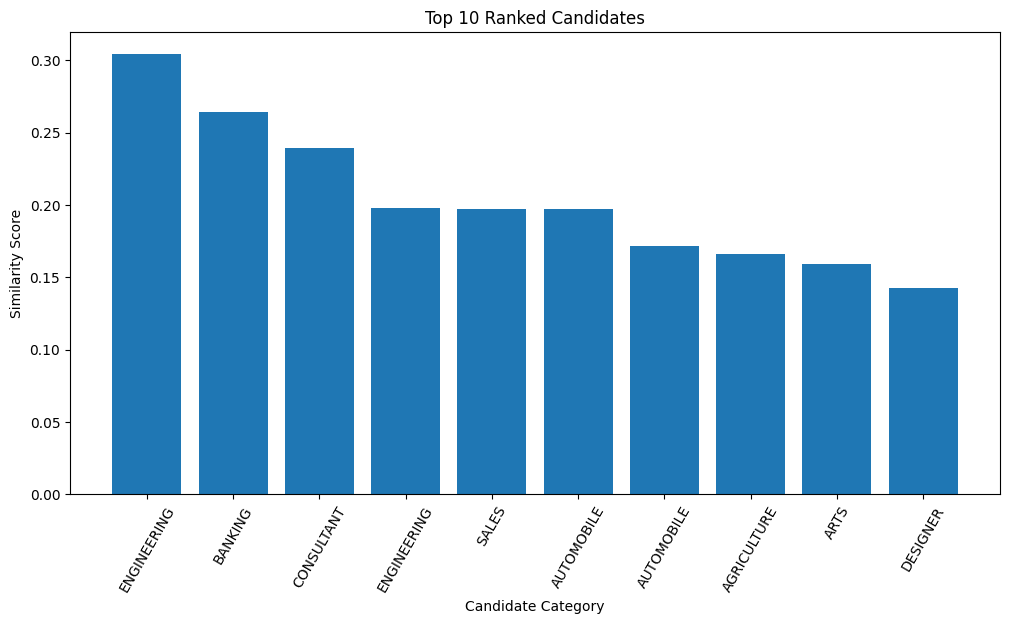

In [18]:
import matplotlib.pyplot as plt

top10 = ranked_candidates.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    range(len(top10)),
    top10["Similarity Score"]
)

plt.xticks(
    range(len(top10)),
    top10["Category"],
    rotation=60
)

plt.title("Top 10 Ranked Candidates")

plt.xlabel("Candidate Category")

plt.ylabel("Similarity Score")

plt.show()

# Conclusion

A Resume Screening and Candidate Ranking System was successfully developed using
Natural Language Processing (NLP) and Machine Learning techniques.

The system performs the following tasks:

- Cleans and preprocesses resume text
- Converts resumes into TF-IDF vectors
- Creates a job description profile
- Calculates similarity scores using Cosine Similarity
- Ranks candidates according to job relevance
- Identifies missing skills in the highest-ranked resume
- Visualizes the top-ranked candidates

This project demonstrates how NLP can automate resume screening and help
recruiters identify the most suitable candidates quickly and efficiently.